# Discrete Adjoint via AD (JAX + Diffrax) — Two-Block Spring-Slider Inversion

This notebook re-implements the two-block forward model in JAX and obtains the gradient by **backpropagating directly through the adaptive ODE stepper** using Diffrax's `RecursiveCheckpointAdjoint`. This is the *discrete* adjoint of the actual time-stepping algorithm — exact for the discretised problem by construction.

**Why this approach.** The continuous adjoint of the two-block system became dual-inconsistent during fast slip events: the adjoint integrates against forward-grid-interpolated Jacobians whose denominator $\tau_V + \eta$ pinches near rupture, producing spurious blowup (Alexe & Sandu, *JCAM* 2009). Forward sensitivity (the previous fix) sidesteps the issue but scales linearly in the number of parameters. Discrete-adjoint-via-AD also sidesteps it — and scales independently of the parameter count, which matters once we want to invert for more than 4 parameters.

**Topology and physics** are unchanged from the existing two-block notebook:
- $\tau_i(V_i,\psi_i) + \eta V_i + (k_0{+}k_{12})u_i - k_{12}u_j = \tau_{0,i} + k_0 V_{\rm bg} t$ (force balance, both blocks)
- $\dot u_i = V_i$, $\dot\psi_i = G(V_i,\psi_i) = \frac{b V_0}{d_c}e^{-(\psi_i-f_0)/b} - \frac{b V_i}{d_c}$ (aging law)
- $\tau(V,\psi) = N a\,\text{arcsinh}(V/(2V_0)\,e^{\psi/a})$ (regularised RS)

**Key implementation choices:**
1. **Algebraic constraint** $\tau + \eta V = \text{rhs}$ is solved via `optimistix.Newton` in $\log V$ inside the ODE RHS. Optimistix is a differentiable implicit-layer library — AD propagates through the root-find via the implicit function theorem, so backprop just works.
2. **Time stepping** uses `diffrax.Tsit5` (5th-order explicit RK with PI step-size control). Saving at the fixed $t_{\rm ref}$ grid happens via `SaveAt(ts=t_ref)` — no separate post-hoc interpolation.
3. **Frozen-IC convention** is preserved: $u_{i,0}$, $\psi_{i,0}$, $\tau_{0,i}$ are computed once from the initial guess and held constant across iterates.


In [3]:
%load_ext autoreload
%autoreload 2

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import diffrax
import optimistix as optx
from scipy.optimize import minimize, Bounds

print(f"JAX:        {jax.__version__}")
print(f"Diffrax:    {diffrax.__version__}")
print(f"Optimistix: {optx.__version__}")
print(f"x64 enabled: {jax.config.read('jax_enable_x64')}")

JAX:        0.10.1
Diffrax:    0.7.2
Optimistix: 0.1.0
x64 enabled: True


## Parameters and Initial Conditions

Identical to the existing two-block notebook so results are directly comparable.


In [4]:
# Parameters - two-block coupled system (Abe & Kato 2013 topology)
#
# Friction parameters can differ between blocks. Per-block keys (a_i, N_i,
# b_i, dc_i, f0_i) are used directly; friction_derivs.block_M also accepts the
# shared keys (a, N, b, dc, f0) as a fallback for back-compatibility.
M = {}

# Shared constants
M['V0']   = 1e-6
M['eta']  = 2.7 * 3.5 / 2.0
M['V_bg'] = 1e-9

# Per-block friction parameters — Abe & Kato (2013), Pattern F regime
# (strongly unstable, chaotic seismic-only oscillations; their Fig. 8 case).
# Block 2 is set "less stable" via L1 > L2  =>  dc1 > dc2  =>  kc1 < kc2.
M['a1']   = 1e-3;    M['a2']   = 1e-3
M['b1']   = 1.2e-3;  M['b2']   = 1.2e-3
M['dc1']  = 1e-4;    M['dc2']  = 0.375 * M['dc1']     # tuned so kc2 = (8/3)*kc1
M['N1']   = 50.0;    M['N2']   = 50.0
M['f0_1'] = 0.6;     M['f0_2'] = 0.6


# Pattern F target ratios (Abe & Kato 2013, Fig. 2c / Fig. 8):
#   k12/k0 = 1.00,  (k0+k12)/kc1 = 0.8,  (k0+k12)/kc2 = 0.3.
k_crit1   = M['N1'] * (M['b1'] - M['a1']) / M['dc1']
k_crit2   = M['N2'] * (M['b2'] - M['a2']) / M['dc2']
M['k0']   = 0.4 * k_crit1     # =>  k0/kc1 = 0.4,  (k0+k12)/kc1 = 0.8
M['k12']  = 0.4 * k_crit1     # =>  k12/k0 = 1.00, (k0+k12)/kc2 = 0.3

V1_init = 1.0e-12
V2_init = 1.0e-12

T = 5e7      # s
print(f"a:  a1={M['a1']},  a2={M['a2']}")
print(f"b:  b1={M['b1']},  b2={M['b2']}")
print(f"N:  N1={M['N1']}, N2={M['N2']}")
print(f"dc: dc1={M['dc1']:.3e}, dc2={M['dc2']:.3e}")
print(f"f0: f0_1={M['f0_1']}, f0_2={M['f0_2']}")
print(f"k0 ={M['k0']:.3e},  k12={M['k12']:.3e}  (MPa/m)")
print(f"k_crit1 ={k_crit1:.3e},  k_crit2={k_crit2:.3e}  (MPa/m)")
print(f"  k12/k0          = {M['k12']/M['k0']:.3f}   (Pattern F: 1.00)")
print(f"  (k0+k12)/k_crit1 = {(M['k0']+M['k12'])/k_crit1:.3f}   (Pattern F: 0.80)")
print(f"  (k0+k12)/k_crit2 = {(M['k0']+M['k12'])/k_crit2:.3f}   (Pattern F: 0.30)")
print(f"T = {T:.2e} s  ({T/86400:.0f} days)")


a:  a1=0.001,  a2=0.001
b:  b1=0.0012,  b2=0.0012
N:  N1=50.0, N2=50.0
dc: dc1=1.000e-04, dc2=3.750e-05
f0: f0_1=0.6, f0_2=0.6
k0 =4.000e+01,  k12=4.000e+01  (MPa/m)
k_crit1 =1.000e+02,  k_crit2=2.667e+02  (MPa/m)
  k12/k0          = 1.000   (Pattern F: 1.00)
  (k0+k12)/k_crit1 = 0.800   (Pattern F: 0.80)
  (k0+k12)/k_crit2 = 0.300   (Pattern F: 0.30)
T = 5.00e+07 s  (579 days)


In [5]:
# Frozen IC + tau0_i (computed once from these params; held constant across iterates)
from friction_derivs import setup_initial_conditions_2block

u1_0, psi1_0, _, u2_0, psi2_0, _ = setup_initial_conditions_2block(
    M, V1_init=V1_init, V2_init=V2_init)
tau0_1 = M['tau0_1']
tau0_2 = M['tau0_2']

print(f"u1_0={u1_0},  psi1_0={psi1_0:.4f},  tau0_1={tau0_1:.6f}")
print(f"u2_0={u2_0},  psi2_0={psi2_0:.4f},  tau0_2={tau0_2:.6f}")

Physics functions defined.
u1_0=0.0,  psi1_0=0.6083,  tau0_1=29.723690
u2_0=0.0,  psi2_0=0.6083,  tau0_2=29.723690


## JAX Physics Primitives

Same equations as `friction_derivs.py`, rewritten in `jnp` so AD can trace them. The constants `f0, V0, b, dc, N, eta, V_bg` are captured by closure as Python floats (they don't appear in the parameter vector and have no gradient).


In [6]:
# Shared constants (truly the same on both blocks)
V0   = M['V0']
eta  = M['eta']
V_bg = M['V_bg']

# Per-block friction constants captured by closure (held fixed across iterates;
# the optimisable parameters a1/a2/k0/k12 enter as `args` of the diffrax ODE).
f0_1, f0_2 = M['f0_1'], M['f0_2']
b1,   b2   = M['b1'],   M['b2']
dc1,  dc2  = M['dc1'],  M['dc2']
N1,   N2   = M['N1'],   M['N2']

def tau_fn(V, psi, a, N):
    # tau = N*a*arcsinh(V/(2V0)*exp(psi/a)), computed in log-space.
    #
    # Forming xi = V/(2V0)*exp(psi/a) directly overflows when psi/a is large:
    # at steady state psi/a ~ 600 for our params, so xi ~ 1e260 and xi**2 > 1e308
    # overflows to inf. arcsinh itself stays finite via lucky cancellation, but
    # AD's reverse pass evaluates 1/sqrt(1+xi**2) which collapses to 0 and silently
    # destroys d(tau)/d(logV). Newton then takes a step of magnitude 1e10 and the
    # next iterate is NaN.
    #
    # Fix: work with log_xi = log(V) - log(2V0) + psi/a, and use
    #   arcsinh(exp(log_xi)) = log_xi + log(1 + sqrt(1 + exp(-2*log_xi)))
    # for log_xi >= 0 (the only regime hit in this problem) — never form xi or xi**2.
    # The small-log_xi branch is kept for safety; the doubled jnp.where pattern
    # masks each branch's inputs so neither produces inf in forward or backward AD.
    log_xi   = jnp.log(V) - jnp.log(2.0 * V0) + psi / a
    is_large = log_xi >= 0.0
    log_xi_l = jnp.where(is_large, log_xi, 0.0)
    arcsinh_large = log_xi_l + jnp.log1p(jnp.sqrt(1.0 + jnp.exp(-2.0 * log_xi_l)))
    log_xi_s = jnp.where(is_large, 0.0, log_xi)
    arcsinh_small = jnp.arcsinh(jnp.exp(log_xi_s))
    return N * a * jnp.where(is_large, arcsinh_large, arcsinh_small)

def G_fn(V, psi, b, dc, f0):
    # aging-law dpsi/dt
    return b * V0 / dc * jnp.exp(-(psi - f0) / b) - b * V / dc


## Differentiable Force-Balance Solver via Optimistix

The algebraic constraint $\tau(V,\psi) + \eta V = \text{rhs}$ is monotone in $V$ (both terms are increasing for $V>0$). We solve it via Newton's method on $\log V$ — log-space keeps the iteration stable across the 12+ orders of magnitude $V$ traverses during a rupture.

`optimistix.root_find` differentiates through the root-find via the implicit function theorem, so backpropagation through this step happens automatically.


In [7]:
def _V_residual_logV(logV, args):
    psi, a, N, rhs = args
    V = jnp.exp(logV)
    return tau_fn(V, psi, a, N) + eta * V - rhs

# Achievable tolerances for double precision. atol below ~1e-13 is unreachable
# because tau involves arcsinh of arguments up to ~1e35, where round-off floor
# is ~ ulp(tau) ~ 1e-14 * |tau|. throw=True so silent non-convergence raises.
_V_solver = optx.Newton(rtol=1e-12, atol=1e-13)

def solve_V(psi, a, N, rhs):
    # Return V > 0 satisfying tau(V,psi) + eta*V = rhs.
    #
    # Initial guess from the friction-dominated approximation (ignoring eta*V):
    #     tau = N*a*arcsinh(V/(2V0)*exp(psi/a)) = rhs
    #   => for arcsinh(x) ≈ ln(2x) (large x, the typical regime here),
    #      V/V0 * exp(psi/a) ≈ exp(rhs/(N*a))
    #   => logV ≈ log(V0) - psi/a + rhs/(N*a)
    # Lands within O(1) in log space even when V spans 12+ orders across rupture.
    logV0 = jnp.log(V0) - psi / a + rhs / (N * a)
    sol = optx.root_find(_V_residual_logV, _V_solver, logV0,
                          args=(psi, a, N, rhs),
                          max_steps=200, throw=True)
    return jnp.exp(sol.value)

# Quick sanity check: solve at the initial state of block 1
rhs_test = tau0_1
V_test = float(solve_V(jnp.asarray(psi1_0), jnp.asarray(M['a1']),
                       jnp.asarray(N1), jnp.asarray(rhs_test)))
print(f"solve_V at IC: V1 = {V_test:.4e}  (V1_init = {V1_init:.4e})")
assert abs(V_test - V1_init) / V1_init < 1e-6, "Force-balance solver disagrees with IC"
print("OK")


solve_V at IC: V1 = 1.0000e-12  (V1_init = 1.0000e-12)
OK


## ODE Vector Field (Two-Block, $V$ Eliminated)

The DAE collapses to a 4-D ODE in $(u_1, \psi_1, u_2, \psi_2)$ once we solve the algebraic $V_i$ constraint inside the RHS. Diffrax sees only the ODE.


In [8]:
def vector_field(t, y, args):
    a1, a2, k0, k12 = args
    u1, psi1, u2, psi2 = y[0], y[1], y[2], y[3]

    rhs1 = tau0_1 + k0 * V_bg * t - (k0 + k12) * u1 + k12 * u2
    rhs2 = tau0_2 + k0 * V_bg * t - (k0 + k12) * u2 + k12 * u1

    V1 = solve_V(psi1, a1, N1, rhs1)
    V2 = solve_V(psi2, a2, N2, rhs2)

    return jnp.stack([V1, G_fn(V1, psi1, b1, dc1, f0_1),
                       V2, G_fn(V2, psi2, b2, dc2, f0_2)])


## Forward Solve with `RecursiveCheckpointAdjoint`

Diffrax's `RecursiveCheckpointAdjoint` performs reverse-mode AD through the actual time-stepping algorithm with logarithmic checkpointing. The official Diffrax docs explicitly recommend it over `BacksolveAdjoint` (the continuous adjoint) for accuracy on stiff or near-stiff systems — which is exactly the failure mode we hit before.

We use `Tsit5` (5th-order explicit RK with PI step control) and tight tolerances. `SaveAt(ts=t_ref)` returns the state on the fixed reference grid that $J$ uses, so no post-hoc interpolation is needed.


In [9]:
# Higher-order solver (8th-order Dopri8) + tighter PI controller tolerances.
# This is the single biggest lever for AD/FD agreement: it shrinks the
# discretisation noise of J(p), making FD a clean reference, AND reduces the
# step-grid wobble that backprop must propagate through.
SOLVER         = diffrax.Dopri8()
RTOL           = 1e-11 # 1e-11
ATOL           = 1e-13 # 1e-13
MAX_STEPS      = 500_000

_controller = diffrax.PIDController(rtol=RTOL, atol=ATOL)
_term       = diffrax.ODETerm(vector_field)
_adjoint    = diffrax.RecursiveCheckpointAdjoint()

def forward_solve_jax(params_vec, t_save):
    # Returns ys: (len(t_save), 4) array of (u1, psi1, u2, psi2) at t_save.
    # t_save may be a traced array under jit; diffrax accepts traced t1.
    a1, a2, k0, k12 = params_vec[0], params_vec[1], params_vec[2], params_vec[3]
    y0 = jnp.array([u1_0, psi1_0, u2_0, psi2_0], dtype=jnp.float64)

    sol = diffrax.diffeqsolve(
        _term, SOLVER,
        t0=0.0, t1=t_save[-1], dt0=1.0,
        y0=y0,
        args=(a1, a2, k0, k12),
        saveat=diffrax.SaveAt(ts=t_save),
        stepsize_controller=_controller,
        adjoint=_adjoint,
        max_steps=MAX_STEPS,
    )
    return sol.ys

# Dry-run at true params to compile + verify
p_true = jnp.array([M['a1'], M['a2'], M['k0'], M['k12']], dtype=jnp.float64)
t_dense = jnp.linspace(0.0, T, 2000)
import time
t0 = time.time(); ys = forward_solve_jax(p_true, t_dense); ys.block_until_ready()
print(f"First (compile+run) forward solve: {time.time()-t0:.2f} s")
t0 = time.time(); ys = forward_solve_jax(p_true, t_dense); ys.block_until_ready()
print(f"Second (cached)   forward solve: {time.time()-t0:.2f} s")
print(f"u1(T) = {float(ys[-1,0]):.4e},  u2(T) = {float(ys[-1,2]):.4e}")

First (compile+run) forward solve: 0.82 s
Second (cached)   forward solve: 0.07 s
u1(T) = 4.1788e-02,  u2(T) = 4.2976e-02


## Plot Forward Solution (sanity-check against the existing numpy solver)


/Users/eric/Desktop/Earthquake Research/Adjoint_project/friction_derivs.py:31: RuntimeWarning: overflow encountered in scalar power
  return M['N'] * M['a'] / np.sqrt(1.0 + xi**2) * xi / V
/Users/eric/Desktop/Earthquake Research/Adjoint_project/friction_derivs.py:36: RuntimeWarning: overflow encountered in scalar power
  return M['N'] * xi / np.sqrt(1.0 + xi**2)
/Users/eric/Desktop/Earthquake Research/Adjoint_project/friction_derivs.py:53: RuntimeWarning: overflow encountered in scalar power
  return M['N'] * np.arcsinh(xi) - M['N'] * psi * xi / (M['a'] * np.sqrt(1.0 + xi**2))


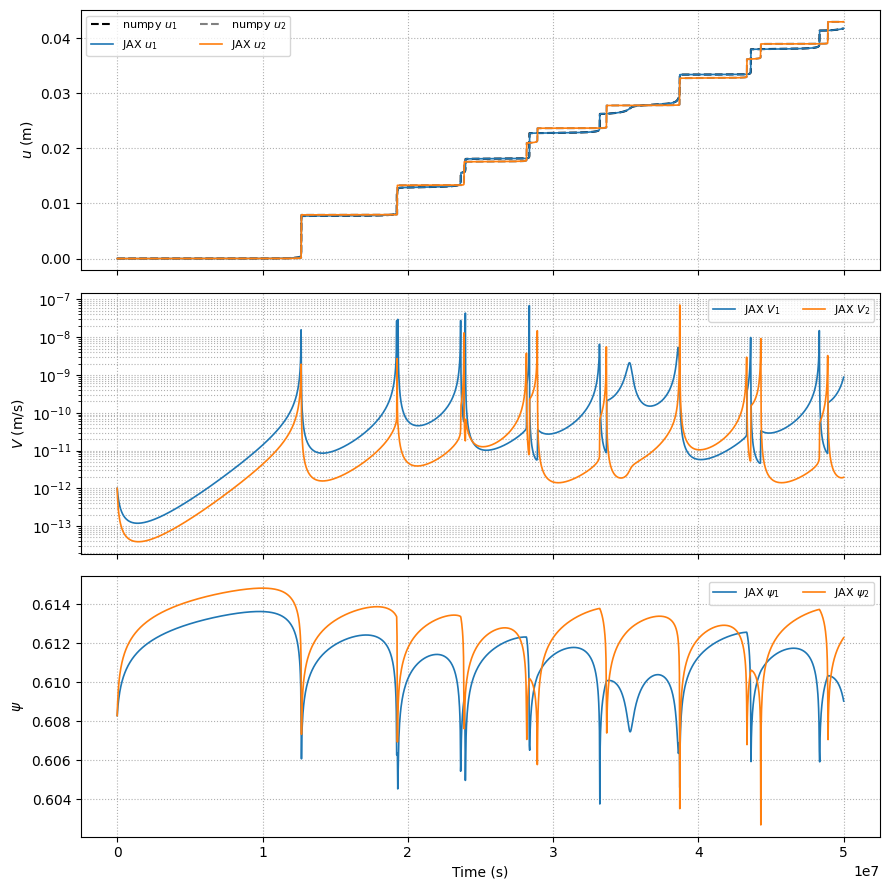

max |u1_JAX - u1_numpy| / max|u1| = 5.24e-04
max |u2_JAX - u2_numpy| / max|u2| = 1.36e-04


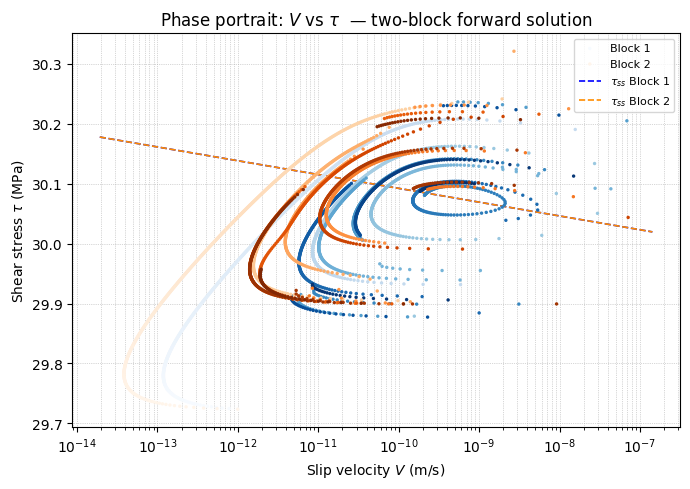

Block 1 slip range: V=1.190e-13 – 6.876e-08 m/s,  u(T)=4.1788e-02 m
Block 2 slip range: V=3.857e-14 – 7.133e-08 m/s,  u(T)=4.2976e-02 m


In [10]:
from adapt_fwd_solve import forward_solve_adaptive_2block

fwd_ref = forward_solve_adaptive_2block(dict(M), T, u1_0, psi1_0, u2_0, psi2_0,
                                         V1_init=V1_init, V2_init=V2_init)

# Recover V_i from the JAX solution at the saved times
V1_jax = np.array([float(solve_V(jnp.asarray(p), jnp.asarray(M['a1']), jnp.asarray(N1),
                                  jnp.asarray(tau0_1 + M['k0']*V_bg*t - (M['k0']+M['k12'])*u + M['k12']*u2)))
                   for t, u, p, u2 in zip(t_dense, ys[:,0], ys[:,1], ys[:,2])])
V2_jax = np.array([float(solve_V(jnp.asarray(p), jnp.asarray(M['a2']), jnp.asarray(N2),
                                  jnp.asarray(tau0_2 + M['k0']*V_bg*t - (M['k0']+M['k12'])*u2 + M['k12']*u1)))
                   for t, u1, p, u2 in zip(t_dense, ys[:,0], ys[:,3], ys[:,2])])

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Row 0: u1, u2
axes[0].plot(fwd_ref['t'], fwd_ref['u1'], 'k--', lw=1.5, label='numpy $u_1$')
axes[0].plot(t_dense,      ys[:, 0],      'C0',  lw=1.2, label='JAX $u_1$')
axes[0].plot(fwd_ref['t'], fwd_ref['u2'], color='0.5', ls='--', lw=1.5, label='numpy $u_2$')
axes[0].plot(t_dense,      ys[:, 2],      'C1',  lw=1.2, label='JAX $u_2$')
axes[0].set_ylabel('$u$ (m)'); axes[0].legend(fontsize=8, ncol=2); axes[0].grid(True, ls=':')

# Row 1: V1, V2 (semilogy)
# axes[1].semilogy(fwd_ref['t'], fwd_ref['V1'], 'k--',                  lw=1.5, label='numpy $V_1$')
axes[1].semilogy(t_dense,      V1_jax,        'C0',                   lw=1.2, label='JAX $V_1$')
# axes[1].semilogy(fwd_ref['t'], fwd_ref['V2'], color='0.5', ls='--',   lw=1.5, label='numpy $V_2$')
axes[1].semilogy(t_dense,      V2_jax,        'C1',                   lw=1.2, label='JAX $V_2$')
axes[1].set_ylabel('$V$ (m/s)')
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(True, ls=':', which='both')

# Row 2: psi1, psi2
# axes[2].plot(fwd_ref['t'], fwd_ref['psi1'], 'k--',                lw=1.5, label='numpy $\\psi_1$')
axes[2].plot(t_dense,      ys[:, 1],        'C0',                 lw=1.2, label='JAX $\\psi_1$')
# axes[2].plot(fwd_ref['t'], fwd_ref['psi2'], color='0.5', ls='--', lw=1.5, label='numpy $\\psi_2$')
axes[2].plot(t_dense,      ys[:, 3],        'C1',                 lw=1.2, label='JAX $\\psi_2$')
axes[2].set_ylabel('$\\psi$'); axes[2].set_xlabel('Time (s)')
axes[2].legend(fontsize=8, ncol=2); axes[2].grid(True, ls=':')

plt.tight_layout(); plt.show()

rel_u1 = np.max(np.abs(np.interp(t_dense, fwd_ref['t'], fwd_ref['u1']) - ys[:, 0])) / np.max(np.abs(fwd_ref['u1']))
rel_u2 = np.max(np.abs(np.interp(t_dense, fwd_ref['t'], fwd_ref['u2']) - ys[:, 2])) / np.max(np.abs(fwd_ref['u2']))
print(f"max |u1_JAX - u1_numpy| / max|u1| = {rel_u1:.2e}")
print(f"max |u2_JAX - u2_numpy| / max|u2| = {rel_u2:.2e}")

# ------------------------------------------------------------------
# Phase portrait: log velocity vs shear stress, both blocks
# ------------------------------------------------------------------
# Recover tau_i(t) along the JAX trajectory from (V_i, psi_i)
psi1_jax = np.asarray(ys[:, 1])
psi2_jax = np.asarray(ys[:, 3])
tau1_fwd = N1 * M['a1'] * np.arcsinh(V1_jax / (2.0 * V0) * np.exp(psi1_jax / M['a1']))
tau2_fwd = N2 * M['a2'] * np.arcsinh(V2_jax / (2.0 * V0) * np.exp(psi2_jax / M['a2']))

# Steady-state friction coefficient: f_ss(V) = f0 + (a - b) * ln(V/V0)
def fss_fn(V, a, b, f0):
    return f0 + (a - b) * np.log(V / V0)

V_min = min(V1_jax.min(), V2_jax.min()) * 0.5
V_max = max(V1_jax.max(), V2_jax.max()) * 2.0
V_ss  = np.geomspace(V_min, V_max, 300)
t     = np.asarray(t_dense)

fig2, ax2 = plt.subplots(figsize=(7, 5))
sc1 = ax2.scatter(V1_jax, tau1_fwd, c=t, cmap='Blues',   s=6, lw=0, zorder=3, label='Block 1')
sc2 = ax2.scatter(V2_jax, tau2_fwd, c=t, cmap='Oranges', s=6, lw=0, zorder=3, label='Block 2')
ax2.plot(V_ss, N1 * fss_fn(V_ss, M['a1'], M['b1'], M['f0_1']), 'b--',        lw=1.2, label=r'$\tau_{ss}$ Block 1')
ax2.plot(V_ss, N2 * fss_fn(V_ss, M['a2'], M['b2'], M['f0_2']), 'darkorange', ls='--', lw=1.2, label=r'$\tau_{ss}$ Block 2')
ax2.set_xscale('log')
ax2.set_xlabel('Slip velocity $V$ (m/s)')
ax2.set_ylabel('Shear stress $\\tau$ (MPa)')
ax2.set_title('Phase portrait: $V$ vs $\\tau$  — two-block forward solution')
ax2.legend(fontsize=8)
ax2.grid(True, ls=':', lw=0.5, which='both')
plt.tight_layout()
plt.show()

print(f"Block 1 slip range: V={V1_jax.min():.3e} – {V1_jax.max():.3e} m/s,  u(T)={float(ys[-1,0]):.4e} m")
print(f"Block 2 slip range: V={V2_jax.min():.3e} – {V2_jax.max():.3e} m/s,  u(T)={float(ys[-1,2]):.4e} m")

## Synthetic Observations and Objective

Generate observations at the true parameters using the JAX forward (so the test is end-to-end self-consistent in the AD framework). Build the fixed reference grid + smoothing matrix.


In [19]:
from friction_derivs import make_smoothing_matrix

sigma_smooth = 0.01*T # 0.01 * T
t_ref_np = np.linspace(0.0, T, 1000)
S_np     = make_smoothing_matrix(t_ref_np, sigma_smooth)

t_ref = jnp.asarray(t_ref_np)
S     = jnp.asarray(S_np)

# True observations on t_ref
ys_obs = forward_solve_jax(p_true, t_ref)
u1_obs = ys_obs[:, 0]
u2_obs = ys_obs[:, 2]
Su1_obs = S @ u1_obs
Su2_obs = S @ u2_obs

print(f"u1_obs(T) = {float(u1_obs[-1]):.4e},  u2_obs(T) = {float(u2_obs[-1]):.4e}")
print(f"t_ref: {len(t_ref_np)} points,  S: {S.shape}")

u1_obs(T) = 4.1788e-02,  u2_obs(T) = 4.2976e-02
t_ref: 1000 points,  S: (1000, 1000)


In [20]:
def J_fn(p_vec):
    ys = forward_solve_jax(p_vec, t_ref)
    u1 = ys[:, 0]
    u2 = ys[:, 2]
    r1 = S @ u1 - Su1_obs
    r2 = S @ u2 - Su2_obs
    return 0.5 * jnp.trapezoid(r1**2 + r2**2, t_ref)

J_and_grad = jax.jit(jax.value_and_grad(J_fn))

# Sanity: J at true params should be ~ 0 (modulo solver tolerance)
J0, g0 = J_and_grad(p_true)
J0.block_until_ready()
print(f"J(p_true) = {float(J0):.4e}   (should be ~0)")
print(f"grad J(p_true) = {np.asarray(g0)}   (should be ~0)")

J(p_true) = 0.0000e+00   (should be ~0)
grad J(p_true) = [0. 0. 0. 0.]   (should be ~0)


## Gradient Validation: Discrete-Adjoint AD vs Finite Differences

The acid test. At a perturbed parameter point (away from the minimum so gradients are nonzero), compare the AD gradient against centred finite differences. Relative agreement to within $\lesssim 10^{-4}$ is the success criterion — anything looser means either the AD or the FD is unreliable.


At p_test (perturbed param idx 2, factor 1.1):
  J = 1.325451e+02
  AD grad = [-3.87983813e+08  4.32198108e+08  1.10717223e+00  1.97043768e+02]
  eps_rel=1.0e-02:  FD = [ 9.67959503e+05 -9.96505439e+05  1.98583093e+01 -5.35337713e+00]
  eps_rel=1.0e-04:  FD = [ 4.02413874e+07 -7.97907633e+07  1.14202470e+00 -1.25144790e+02]
  eps_rel=1.0e-06:  FD = [3.11474882e+07 1.41398529e+07 1.08199329e+00 1.96871638e+02]
  eps_rel=1.0e-08:  FD = [-3.87687080e+08  4.31861093e+08  1.07667087e+00  1.96862378e+02]
  eps_rel=1.0e-10:  FD = [-3.87755990e+08  4.32040111e+08  8.33741157e-01  1.98289559e+02]

param    best eps_rel        FD (best)               AD     |AD-FD|/|FD|
----------------------------------------------------------------------------
a1            1.0e-10    -3.877560e+08    -3.879838e+08         5.88e-04
a2            1.0e-10    +4.320401e+08    +4.321981e+08         3.66e-04
k0            1.0e-06    +1.081993e+00    +1.107172e+00         2.33e-02
k12           1.0e-06    +1.968716e

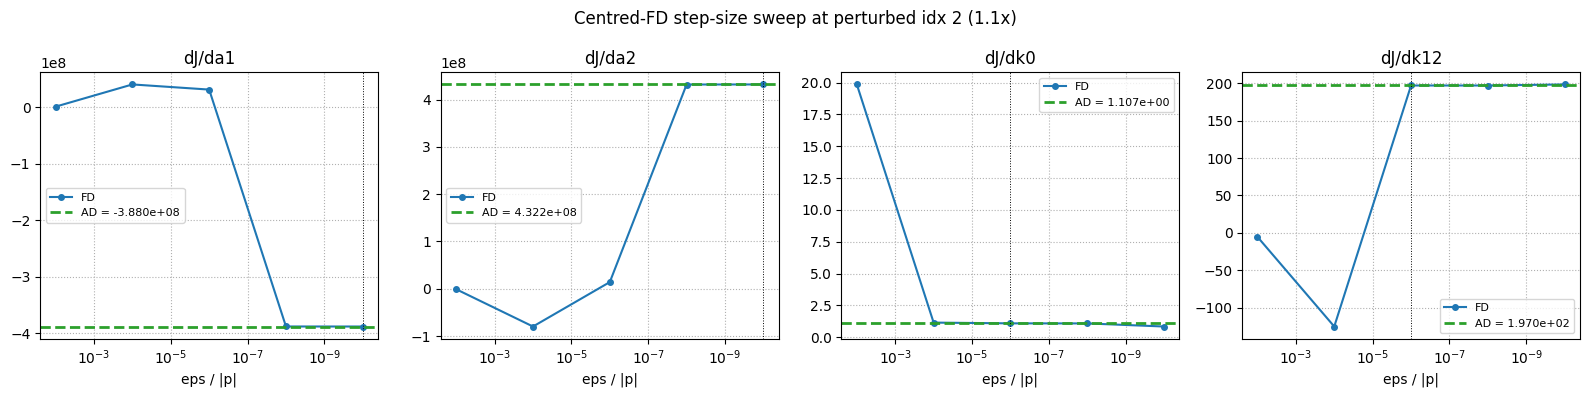

In [21]:
PERTURB_IDX = 2     # 0=a1, 1=a2, 2=k0, 3=k12
PERTURB_F   = 1.1

p_test = p_true.at[PERTURB_IDX].set(p_true[PERTURB_IDX] * PERTURB_F)
J_test, g_ad = J_and_grad(p_test)
J_test.block_until_ready()
g_ad_np = np.asarray(g_ad)
print(f"At p_test (perturbed param idx {PERTURB_IDX}, factor {PERTURB_F}):")
print(f"  J = {float(J_test):.6e}")
print(f"  AD grad = {g_ad_np}")

# -------------------------------------------------------------
# Sweep centred-FD step size across many orders of magnitude.
# The U-shape: for very small eps, noise/eps dominates;
# for very large eps, O(eps^2) truncation bias dominates.
# The plateau between is the trustworthy region.
# -------------------------------------------------------------
EPS_REL = np.logspace(-2, -10, 5)
g_fd_sweep = np.zeros((len(EPS_REL), 4))

for k, eps_rel in enumerate(EPS_REL):
    for i in range(4):
        eps = float(p_test[i]) * eps_rel
        pp = p_test.at[i].set(p_test[i] + eps)
        pm = p_test.at[i].set(p_test[i] - eps)
        Jp, _ = J_and_grad(pp)
        Jm, _ = J_and_grad(pm)
        g_fd_sweep[k, i] = (float(Jp) - float(Jm)) / (2.0 * eps)
    print(f"  eps_rel={eps_rel:.1e}:  FD = {g_fd_sweep[k]}")

# Pick best eps per param: the one with smallest |AD - FD| relative error
best_eps_idx = np.array([
    int(np.argmin(np.abs(g_fd_sweep[:, i] - g_ad_np[i]) / (abs(g_ad_np[i]) + 1e-30)))
    for i in range(4)
])
g_fd_best  = np.array([g_fd_sweep[best_eps_idx[i], i] for i in range(4)])
eps_best   = np.array([EPS_REL[best_eps_idx[i]]       for i in range(4)])

print(f"\n{'param':<6} {'best eps_rel':>14} {'FD (best)':>16} {'AD':>16} {'|AD-FD|/|FD|':>16}")
print('-' * 76)
for i, name in enumerate(['a1', 'a2', 'k0', 'k12']):
    rel = abs(g_ad_np[i] - g_fd_best[i]) / (abs(g_fd_best[i]) + 1e-30)
    print(f"{name:<6} {eps_best[i]:>14.1e} {g_fd_best[i]:+16.6e} {g_ad_np[i]:+16.6e} {rel:16.2e}")

# Plot FD vs eps for each parameter to visualise the noise floor
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i, name in zip(axes, range(4), ['a1', 'a2', 'k0', 'k12']):
    ax.semilogx(EPS_REL, g_fd_sweep[:, i], 'o-', ms=4, color='C0', label='FD')
    ax.axhline(g_ad_np[i], color='C2', lw=2, ls='--', label=f'AD = {g_ad_np[i]:.3e}')
    ax.axvline(eps_best[i], color='k', lw=0.7, ls=':')
    ax.set_xlabel('eps / |p|'); ax.set_title(f'dJ/d{name}'); ax.grid(True, ls=':')
    ax.legend(fontsize=8); ax.invert_xaxis()
fig.suptitle(f'Centred-FD step-size sweep at perturbed idx {PERTURB_IDX} ({PERTURB_F}x)')
plt.tight_layout(); plt.show()

# Keep the best estimates for the bar-chart cell below
g_fd = g_fd_best

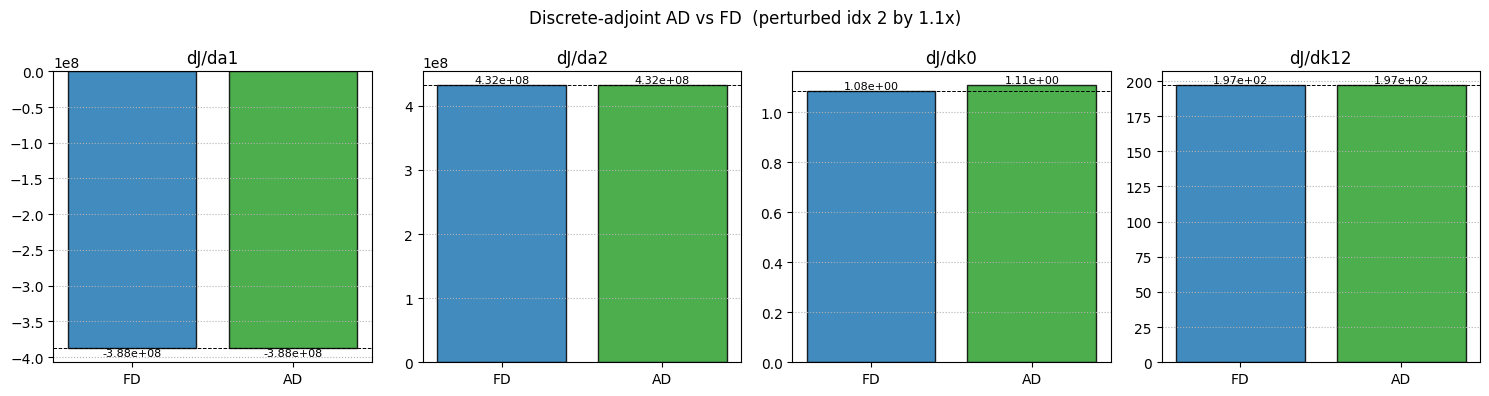

In [22]:
# Bar-chart comparison
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, i, name in zip(axes, range(4), ['a1', 'a2', 'k0', 'k12']):
    vals = [g_fd[i], g_ad_np[i]]
    bars = ax.bar(['FD', 'AD'], vals, color=['C0', 'C2'], alpha=0.85, edgecolor='k')
    ax.axhline(g_fd[i], color='k', ls='--', lw=0.7)
    ax.set_title(f'dJ/d{name}')
    ax.grid(True, ls=':', axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v, f'{v:.2e}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
fig.suptitle(f'Discrete-adjoint AD vs FD  (perturbed idx {PERTURB_IDX} by {PERTURB_F}x)')
plt.tight_layout(); plt.show()

## Objective Function Landscape Scan

Scan $J(p)$ along each parameter axis using the JAX/Diffrax forward and the discrete-adjoint AD gradient. Same plotting style as `run_J_landscape` in the forward-sensitivity notebook (4 Gaussian smoothing levels, log-scale lower panel, optional gradient arrows from `jax.value_and_grad`).

The `Inversion` curve uses the same `sigma_smooth` the optimizer sees, so its minimum should coincide with the optimizer's basin. The frozen-IC convention is already baked into `forward_solve_jax` by closure.



Landscape: a1  (true = 0.001)
Evaluating 60 parameter values x 4 smoothing cases ...
  [8/60]  a1=0.00077119
  [16/60]  a1=0.00085254
  [24/60]  a1=0.0009339
  [32/60]  a1=0.0010153
  [40/60]  a1=0.0010966
  [48/60]  a1=0.001178
  [56/60]  a1=0.0012593
  [60/60]  a1=0.0013
  Done in 110.1 s (0.46 s/eval)


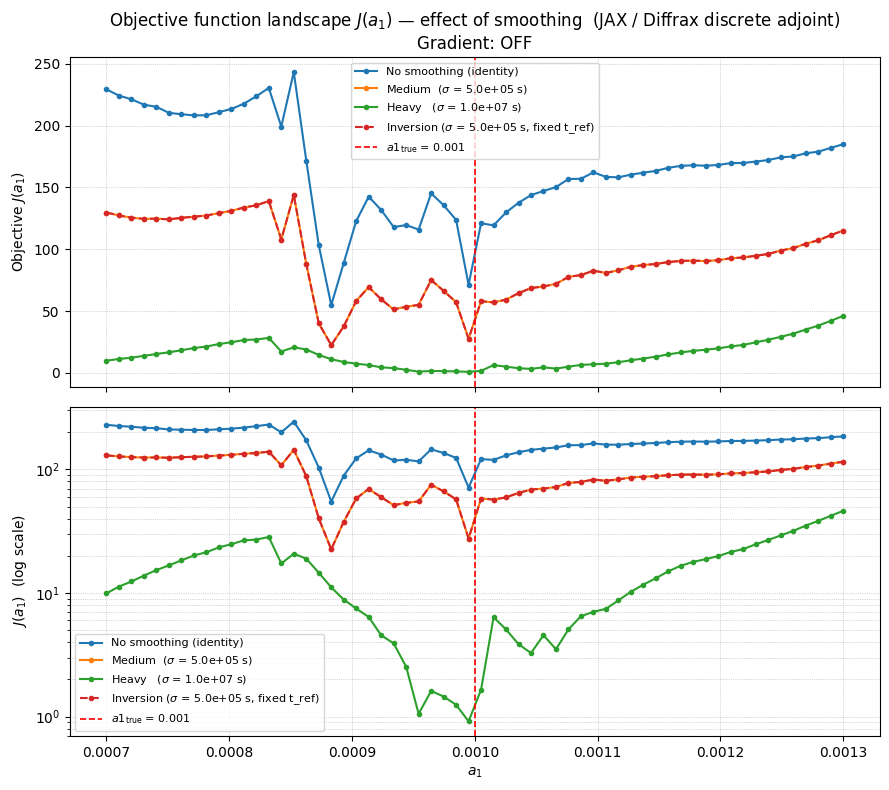


No smoothing (identity)                                       min J = 5.491e+01  at a1 = 0.00088305
Medium  ($\sigma$ = 5.0e+05 s)                                min J = 2.253e+01  at a1 = 0.00088305
Heavy   ($\sigma$ = 1.0e+07 s)                                min J = 9.151e-01  at a1 = 0.00099492
Inversion ($\sigma$ = 5.0e+05 s, fixed t_ref)                 min J = 2.253e+01  at a1 = 0.00088305


In [36]:
from adjoint_tests import run_J_landscape_jax

landscape_results = run_J_landscape_jax(
    M_true=M,
    T=T,
    forward_solve_jax=forward_solve_jax,
    u1_obs=np.asarray(u1_obs),
    u2_obs=np.asarray(u2_obs),
    t_ref=np.asarray(t_ref),
    landscape_params=['a1'],
    compute_gradient=False,
    sigma_inversion=sigma_smooth,
)


## Inversion via `scipy.optimize.minimize` with the AD Gradient

Same setup as the existing forward-sensitivity notebook: invert for $\{a_1, a_2, k_0, k_{12}\}$, parameters normalised by their initial guesses (so all components are $O(1)$ inside the optimiser), `trust-constr` with bounds.

The only thing that changed under the hood is the gradient source: now `jax.value_and_grad(J)` via discrete backprop through Diffrax.


In [23]:
INVERT_PARAMS = ['a1', 'a2', 'k0', 'k12']
PARAM_IDX = {'a1': 0, 'a2': 1, 'k0': 2, 'k12': 3}

_p_true_d = {p: M[p] for p in INVERT_PARAMS}
_p_init_d = {
    'a1':  M['a1']  * 1.1,
    'a2':  M['a2']  * 0.9,
    'k0':  M['k0']  * 0.9,
    'k12': M['k12'] * 1.1,
}
_p_bnds_d = {p: (_p_true_d[p] * 0.5, _p_true_d[p] * 1.5) for p in INVERT_PARAMS}

scales = np.array([_p_init_d[p] for p in INVERT_PARAMS])
x0     = np.array([_p_init_d[p] for p in INVERT_PARAMS]) / scales
lb     = np.array([_p_bnds_d[p][0] for p in INVERT_PARAMS]) / scales
ub     = np.array([_p_bnds_d[p][1] for p in INVERT_PARAMS]) / scales

J_hist, x_hist, grad_hist = [], [], []

def fun_and_grad(x_norm):
    p_full = np.array([M[p] for p in ['a1', 'a2', 'k0', 'k12']])
    for i, name in enumerate(INVERT_PARAMS):
        p_full[PARAM_IDX[name]] = float(x_norm[i] * scales[i])
    p_vec = jnp.asarray(p_full)
    Jv, gv = J_and_grad(p_vec)
    Jv.block_until_ready()
    g_full = np.asarray(gv)
    g_active = np.array([g_full[PARAM_IDX[name]] for name in INVERT_PARAMS])

    J_hist.append(float(Jv))
    x_hist.append(x_norm * scales)
    grad_hist.append(g_active.copy())

    it = len(J_hist)
    pstr = ',  '.join(
        f"{name}={float(x_norm[i]*scales[i]):.6g} "
        f"({abs(float(x_norm[i]*scales[i])-_p_true_d[name])/_p_true_d[name]*100:.3f}% err)"
        for i, name in enumerate(INVERT_PARAMS))
    print(f"eval {it:3d}: J={float(Jv):.4e},  {pstr}")
    return float(Jv), g_active * scales

print(f"Inverting for: {INVERT_PARAMS}")
print(f"Initial: {[_p_init_d[p] for p in INVERT_PARAMS]}")
print(f"True:    {[_p_true_d[p] for p in INVERT_PARAMS]}")

Inverting for: ['a1', 'a2', 'k0', 'k12']
Initial: [0.0011, 0.0009000000000000001, 35.99999999999998, 43.99999999999997]
True:    [0.001, 0.001, 39.99999999999997, 39.99999999999997]


In [28]:
# ============================================================
# Inversion -- choose method
# ============================================================
# METHOD = 'basinhopping' : global optimisation with L-BFGS-B local steps
#                            (random kicks accept/reject by Metropolis).
# METHOD = 'multistart'   : parallel L-BFGS-B from Latin-hypercube-sampled
#                            starts. Threads share the JIT-cached
#                            `J_and_grad`, so there is no per-worker
#                            recompilation. Better for non-convex landscapes
#                            with several basins than basinhopping's random
#                            walk, and trivially parallel.
#
# Both branches populate J_hist / x_hist / x_final, so the downstream
# convergence-summary, convergence-plots, history-viewer, and
# "optimal vs initial vs true" cells run unchanged in either mode.

METHOD = 'basinhopping'   # 'basinhopping' or 'multistart'

J_hist.clear(); x_hist.clear(); grad_hist.clear()

if METHOD == 'basinhopping':
    from scipy.optimize import basinhopping, Bounds

    minimizer_kwargs = dict(
        method='L-BFGS-B', jac=True, bounds=Bounds(lb, ub),
        options=dict(ftol=1e-4, gtol=1e-3, maxiter=30, maxfun=50),
    )

    result = basinhopping(
        func=fun_and_grad,
        x0=x0,
        minimizer_kwargs=minimizer_kwargs,
        niter=400,          # global random jumps
        stepsize=0.08,      # max size of jump (normalised units)
        T=6.0,              # acceptance temperature
        disp=True,
    )

    x_final = result.x * scales
    print(f"\n{result.message}")

elif METHOD == 'multistart':
    from scipy.optimize import minimize, Bounds
    from scipy.stats.qmc import LatinHypercube
    from concurrent.futures import ThreadPoolExecutor, as_completed

    # ---- multistart knobs ----
    N_STARTS    = 84          # total local optimisations
    MAX_WORKERS = 4           # parallel threads sharing the JIT cache
    RNG_SEED    = 0
    LOCAL_OPTS  = dict(ftol=1e-4, gtol=1e-3, maxiter=50, maxfun=80)
    INCLUDE_X0  = True        # first start = original x0 (the rest are LHS)
    # --------------------------

    # Latin-hypercube sample in [lb, ub] (normalised units).
    sampler     = LatinHypercube(d=len(INVERT_PARAMS), seed=RNG_SEED)
    starts_unit = sampler.random(N_STARTS)
    starts      = lb + starts_unit * (ub - lb)
    if INCLUDE_X0:
        starts[0] = x0

    def _local_minimise(args):
        # Each worker keeps its own history list to avoid interleaved
        # writes into the global lists. Histories are concatenated in
        # deterministic start-index order after all workers return.
        idx, x_start = args
        local_J, local_x, local_g = [], [], []

        def _fg(x_norm):
            p_full = np.array([M[p] for p in ['a1', 'a2', 'k0', 'k12']])
            for i, name in enumerate(INVERT_PARAMS):
                p_full[PARAM_IDX[name]] = float(x_norm[i] * scales[i])
            Jv, gv = J_and_grad(jnp.asarray(p_full))
            Jv.block_until_ready()
            g_full   = np.asarray(gv)
            g_active = np.array([g_full[PARAM_IDX[name]] for name in INVERT_PARAMS])
            local_J.append(float(Jv))
            local_x.append(x_norm * scales)
            local_g.append(g_active.copy())
            return float(Jv), g_active * scales

        res = minimize(
            fun=_fg, x0=x_start, method='L-BFGS-B', jac=True,
            bounds=Bounds(lb, ub), options=LOCAL_OPTS,
        )
        return idx, res, local_J, local_x, local_g

    print(f"Multistart: {N_STARTS} starts, {MAX_WORKERS} parallel threads")
    print(f"  (LHS sampled within bounds"
          + (", first start = original x0)" if INCLUDE_X0 else ")"))

    results = [None] * N_STARTS
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as exe:
        futs = {exe.submit(_local_minimise, (i, starts[i])): i
                for i in range(N_STARTS)}
        for fut in as_completed(futs):
            i, res, lJ, lx, lg = fut.result()
            results[i] = (res, lJ, lx, lg)
            x_phys = res.x * scales
            pstr = ', '.join(
                f"{name}={x_phys[j]:.4g} "
                f"({abs(x_phys[j]-_p_true_d[name])/_p_true_d[name]*100:.2f}% err)"
                for j, name in enumerate(INVERT_PARAMS))
            print(f"  start {i:2d}: J={res.fun:.4e}, {res.nfev:3d} evals  |  {pstr}")

    # Concatenate per-start histories in start-index order so the downstream
    # convergence plot reads as a sawtooth (one descent per start).
    for res, lJ, lx, lg in results:
        J_hist.extend(lJ); x_hist.extend(lx); grad_hist.extend(lg)

    best_i  = int(np.argmin([r[0].fun for r in results]))
    result  = results[best_i][0]
    x_final = result.x * scales

    print(f"\nBest start: {best_i}  (J={result.fun:.4e})")

else:
    raise ValueError(f"Unknown METHOD={METHOD!r}; "
                     "use 'basinhopping' or 'multistart'.")

print()
for i, name in enumerate(INVERT_PARAMS):
    tv = _p_true_d[name]; fv = x_final[i]
    print(f"  {name}: {fv:.6g}  (true={tv:.6g},  err={abs(fv-tv)/tv*100:.4f}%)")
print(f"Total evaluations: {len(J_hist)}")

eval   1: J=1.2217e+02,  a1=0.0011 (10.000% err),  a2=0.0009 (10.000% err),  k0=36 (10.000% err),  k12=44 (10.000% err)
eval   2: J=1.0119e+04,  a1=0.0005 (50.000% err),  a2=0.0005 (50.000% err),  k0=20 (50.000% err),  k12=20 (50.000% err)
eval   3: J=1.3848e+02,  a1=0.00107337 (7.337% err),  a2=0.000882248 (11.775% err),  k0=35.2899 (11.775% err),  k12=42.9349 (7.337% err)
eval   4: J=1.3241e+02,  a1=0.00109564 (9.564% err),  a2=0.000897091 (10.291% err),  k0=35.8836 (10.291% err),  k12=43.8254 (9.564% err)
eval   5: J=1.2239e+02,  a1=0.00109947 (9.947% err),  a2=0.000899646 (10.035% err),  k0=35.9859 (10.035% err),  k12=43.9788 (9.947% err)
eval   6: J=1.2180e+02,  a1=0.0010999 (9.990% err),  a2=0.000899934 (10.007% err),  k0=35.9974 (10.007% err),  k12=43.9961 (9.990% err)
eval   7: J=1.2283e+02,  a1=0.00109983 (9.983% err),  a2=0.00089989 (10.011% err),  k0=35.9956 (10.011% err),  k12=43.9934 (9.983% err)
eval   8: J=1.2178e+02,  a1=0.0010999 (9.990% err),  a2=0.000899932 (10.007% 

In [30]:
# Convergence speed summary: how many evaluations to drive J below each threshold.
# Useful for comparing the effect of sigma_smooth on inversion efficiency.
J_arr = np.array(J_hist)
thresholds = [1e2, 2e1, 1.5e1, 1e0, 1e-1, 1e-2]

print(f"Convergence summary  (sigma_smooth = {sigma_smooth:.3e} s = {sigma_smooth/T:.2%} of T)")
print(f"  Total evaluations:  {len(J_arr)}")
print(f"  Initial J:          {J_arr[0]:.4e}")
print(f"  Final J:            {J_arr[-1]:.4e}")
print(f"  Best J:             {J_arr.min():.4e}  (at eval {int(np.argmin(J_arr))+1})")
print(f"\n  Evaluations to first reach J below threshold:")
for thr in thresholds:
    below = np.where(J_arr < thr)[0]
    if below.size > 0:
        print(f"    J < {thr:.1e}:  {below[0]+1:4d} evals")
    else:
        print(f"    J < {thr:.1e}:  never reached")


Convergence summary  (sigma_smooth = 5.000e+05 s = 1.00% of T)
  Total evaluations:  10931
  Initial J:          1.2217e+02
  Final J:            6.7193e+01
  Best J:             1.5912e+01  (at eval 6665)

  Evaluations to first reach J below threshold:
    J < 1.0e+02:    75 evals
    J < 2.0e+01:   650 evals
    J < 1.5e+01:  never reached
    J < 1.0e+00:  never reached
    J < 1.0e-01:  never reached
    J < 1.0e-02:  never reached


## Convergence Plots


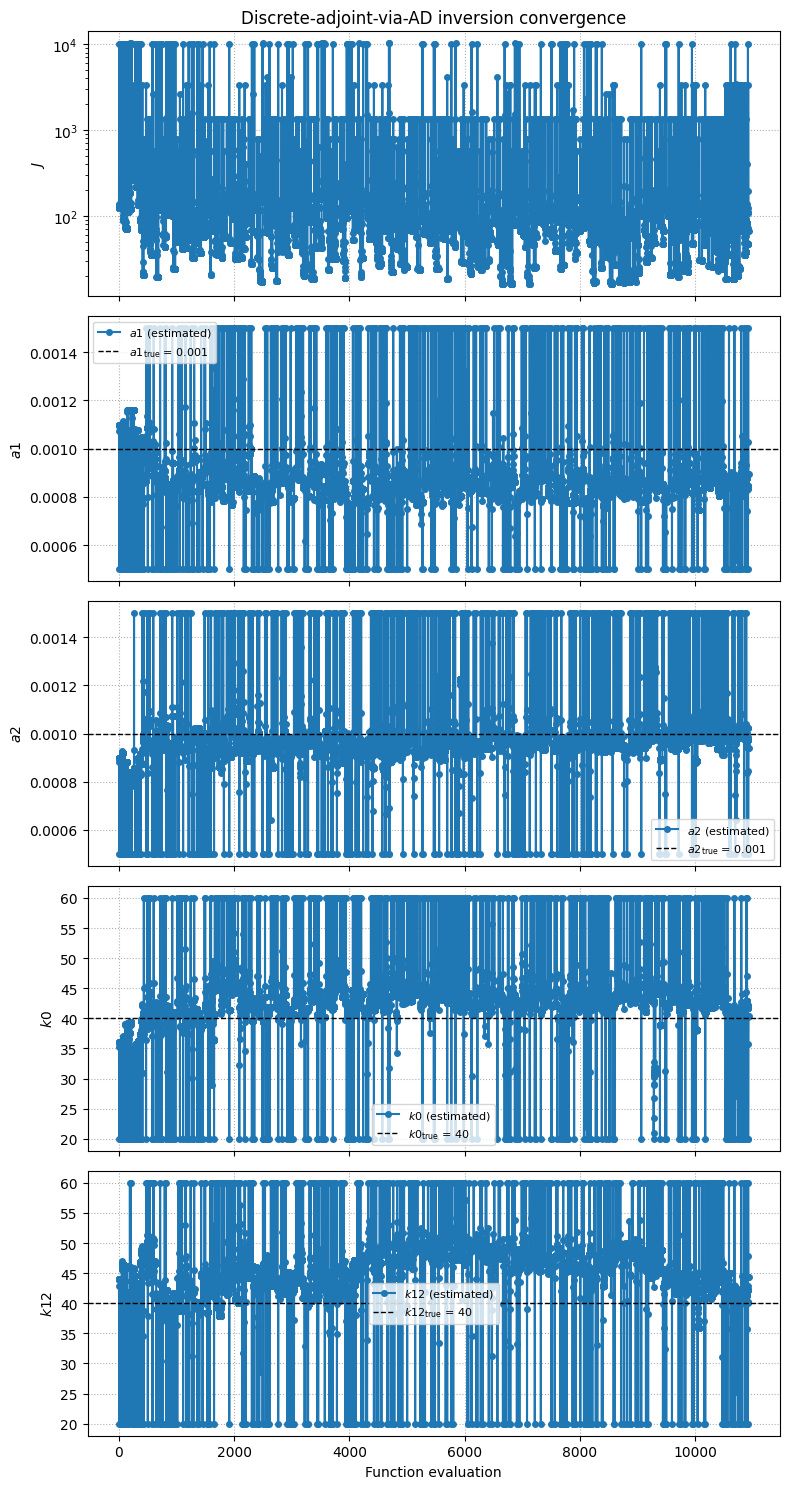


Final parameter estimates:
  a1: 0.000825321  (true=0.001,  err=17.4679%)
  a2: 0.000953404  (true=0.001,  err=4.6596%)
  k0: 42.7182  (true=40,  err=6.7954%)
  k12: 47.5093  (true=40,  err=18.7733%)


In [31]:
n_evals = len(J_hist)
iters = np.arange(1, n_evals + 1)
x_arr = np.array(x_hist)

fig, axes = plt.subplots(1 + len(INVERT_PARAMS), 1,
                          figsize=(8, 3 * (1 + len(INVERT_PARAMS))), sharex=True)
axes[0].semilogy(iters, J_hist, 'o-', ms=4)
axes[0].set_ylabel('$J$')
axes[0].set_title('Discrete-adjoint-via-AD inversion convergence')
axes[0].grid(True, ls=':')

for i, name in enumerate(INVERT_PARAMS):
    ax = axes[1 + i]
    ax.plot(iters, x_arr[:, i], 'o-', ms=4, label=f'${name}$ (estimated)')
    ax.axhline(_p_true_d[name], color='k', ls='--', lw=1.0,
               label=f'${name}_{{\\rm true}}$ = {_p_true_d[name]:.5g}')
    ax.set_ylabel(f'${name}$')
    ax.legend(fontsize=8); ax.grid(True, ls=':')

axes[-1].set_xlabel('Function evaluation')
plt.tight_layout(); plt.show()

print('\nFinal parameter estimates:')
for i, name in enumerate(INVERT_PARAMS):
    print(f"  {name}: {x_final[i]:.6g}  (true={_p_true_d[name]:.6g},  "
          f"err={abs(x_final[i]-_p_true_d[name])/_p_true_d[name]*100:.4f}%)")

## Displacement History Viewer

Recomputes $u_1(t),\,u_2(t)$ at every optimiser evaluation from `x_hist`, then exposes an iteration slider that overlays the current iterate against the true observations and the best iterate found.

In [ ]:
%matplotlib widget
import ipywidgets as widgets


# Numpy mirrors of the JAX arrays (widgets / matplotlib want numpy).
t_ref_plot = np.asarray(t_ref)
S_fixed    = np.asarray(S)
u1_obs_ref = np.asarray(u1_obs)
u2_obs_ref = np.asarray(u2_obs)

PLOT_SMOOTHED = True

# Recompute u1, u2 for each iterate stored in x_hist
n_evals    = len(J_hist)
u1_hist    = np.zeros((n_evals, t_ref_plot.size))
u2_hist    = np.zeros((n_evals, t_ref_plot.size))
param_hist = {p: np.empty(n_evals) for p in INVERT_PARAMS}
_param_true = {p: _p_true_d[p] for p in INVERT_PARAMS}

_p_base = np.array([M[p] for p in ['a1', 'a2', 'k0', 'k12']])
for k in range(n_evals):
    p_full = _p_base.copy()
    for i, name in enumerate(INVERT_PARAMS):
        p_full[PARAM_IDX[name]] = float(x_hist[k][i])
        param_hist[name][k]     = float(x_hist[k][i])
    ys_k = forward_solve_jax(jnp.asarray(p_full), t_ref)
    u1_hist[k] = np.asarray(ys_k[:, 0])
    u2_hist[k] = np.asarray(ys_k[:, 2])

opt_idx = int(np.argmin(J_hist))
print(f"Best iterate: {opt_idx}/{n_evals-1}  (J={J_hist[opt_idx]:.4e})")

fig_int, (ax1_int, ax2_int) = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
fig_int.suptitle("Optimization iteration viewer")

def _smooth_int(u):
    return S_fixed @ u if PLOT_SMOOTHED else u



# Best-iteration lines (silver, fixed)
ax1_int.plot(t_ref_plot, _smooth_int(u1_hist[opt_idx]), color='silver', lw=1.5, label=f'best (iter {opt_idx})')
ax2_int.plot(t_ref_plot, _smooth_int(u2_hist[opt_idx]), color='silver', lw=1.5, label=f'best (iter {opt_idx})')

# Mutable current-iteration lines (initialized at best iteration)
(line_int1,) = ax1_int.plot(t_ref_plot, _smooth_int(u1_hist[opt_idx]), color='C0', lw=1.5, label=f'iter {opt_idx}')
(line_int2,) = ax2_int.plot(t_ref_plot, _smooth_int(u2_hist[opt_idx]), color='C0', lw=1.5, label=f'iter {opt_idx}')

# Static true lines
ax1_int.plot(t_ref_plot, _smooth_int(u1_obs_ref), 'k--', lw=2, label='true u1')
ax2_int.plot(t_ref_plot, _smooth_int(u2_obs_ref), 'k--', lw=2, label='true u2')

for ax, ylabel in zip([ax1_int, ax2_int], ['u1 (m)', 'u2 (m)']):
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

fig_int.tight_layout()

def _update_int(iteration):
    line_int1.set_ydata(_smooth_int(u1_hist[iteration]))
    line_int2.set_ydata(_smooth_int(u2_hist[iteration]))
    param_strs = [f"{p}={param_hist[p][iteration]:.4g} (true {_param_true[p]:.4g})"
                  for p in INVERT_PARAMS]
    fig_int.suptitle(
        f"iter {iteration}/{n_evals-1}  |  J={J_hist[iteration]:.4g}  |  " + ",  ".join(param_strs)
    )
    fig_int.canvas.draw_idle()

slider_int = widgets.IntSlider(
    value=opt_idx, min=0, max=n_evals - 1, step=1,
    description='Iteration', continuous_update=True,
    layout=widgets.Layout(width='80%')
)
widgets.interact(_update_int, iteration=slider_int)


## Optimal vs Initial vs True Displacement

Standalone summary plot — one panel per spring-slider block — overlaying the optimal estimate (from the inversion), the original initial guess, and the true displacement on the same axes. Recomputes each curve from scratch via `forward_solve_jax`, so this cell can be re-run without depending on the iteration-viewer state above. Requires the inversion cell to have run (uses `result.x`, `scales`, `_p_init_d`, `_p_true_d`, `INVERT_PARAMS`).


Best iterate: 6664/10930  (J = 1.5912e+01)
  a1: 0.000825321  (true=0.001,  err=17.4679%)
  a2: 0.000953404  (true=0.001,  err=4.6596%)
  k0: 42.7182  (true=40,  err=6.7954%)
  k12: 47.5093  (true=40,  err=18.7733%)


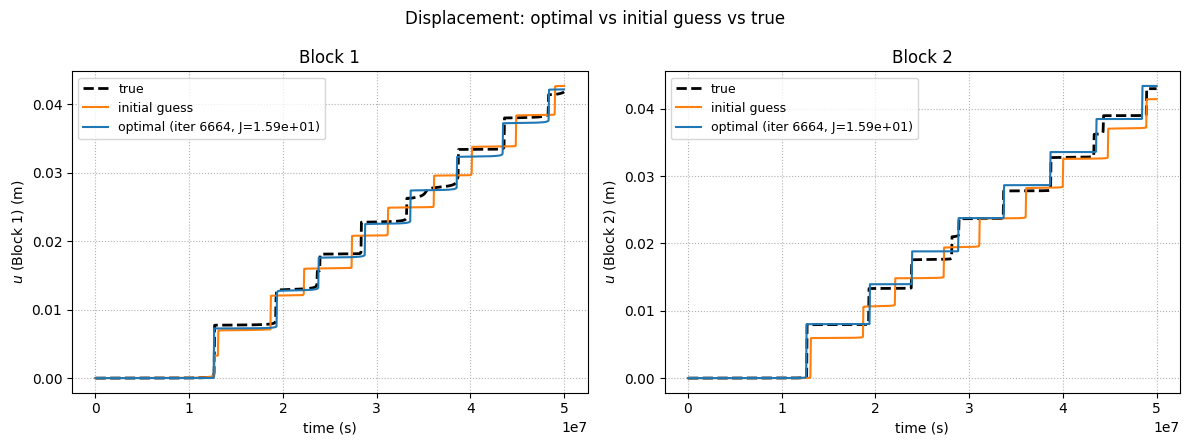

In [32]:
# Optimal vs initial guess vs true displacement (one panel per block).
# Independent of the iteration viewer: rebuilds each parameter vector from
# scratch and recomputes the forward solve at t_ref.
#
# "Optimal" here = the iterate in x_hist with the lowest J in J_hist
# (the best point the optimizer ever visited), not result.x (which for
# basinhopping is the last local-minimum endpoint and may be worse).

_best_idx = int(np.argmin(J_hist))
_x_best   = np.asarray(x_hist[_best_idx])   # already in unnormalised units

_p_base   = np.array([M[p] for p in ['a1', 'a2', 'k0', 'k12']])
p_init    = _p_base.copy()
p_opt     = _p_base.copy()
p_true_v  = _p_base.copy()   # all four match M

for i, name in enumerate(INVERT_PARAMS):
    p_init[PARAM_IDX[name]]    = _p_init_d[name]
    p_opt[PARAM_IDX[name]]     = float(_x_best[i])
    p_true_v[PARAM_IDX[name]]  = _p_true_d[name]

print(f"Best iterate: {_best_idx}/{len(J_hist)-1}  (J = {J_hist[_best_idx]:.4e})")
for i, name in enumerate(INVERT_PARAMS):
    tv = _p_true_d[name]; fv = float(_x_best[i])
    print(f"  {name}: {fv:.6g}  (true={tv:.6g},  err={abs(fv-tv)/tv*100:.4f}%)")

ys_init = np.asarray(forward_solve_jax(jnp.asarray(p_init),   t_ref))
ys_opt  = np.asarray(forward_solve_jax(jnp.asarray(p_opt),    t_ref))
ys_true = np.asarray(forward_solve_jax(jnp.asarray(p_true_v), t_ref))

t_plot = np.asarray(t_ref)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, idx, title in zip(axes, [0, 2], ['Block 1', 'Block 2']):
    ax.plot(t_plot, ys_true[:, idx], 'k--', lw=2,   label='true')
    ax.plot(t_plot, ys_init[:, idx], 'C1',  lw=1.5, label='initial guess')
    ax.plot(t_plot, ys_opt[:,  idx], 'C0',  lw=1.5, label=f'optimal (iter {_best_idx}, J={J_hist[_best_idx]:.2e})')
    ax.set_xlabel('time (s)')
    ax.set_ylabel(f'$u$ ({title}) (m)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, ls=':')

fig.suptitle('Displacement: optimal vs initial guess vs true')
fig.tight_layout()
plt.show()


## 2D Objective Landscape Surface

Sweep $J$ over a 2D grid of two parameters and render the $\log_{10} J$ surface plus a companion contour plot. Evaluations are batched-parallel via `jax.vmap`: each chunk of `chunk_size` parameter vectors is dispatched as one XLA computation, so XLA can parallelise the diffrax solves internally across CPU threads (or GPU streams). Increase `chunk_size` for more concurrency, decrease it if peak memory becomes a problem.

`n1`, `n2` set the sampling density along each axis (total evaluations = `n1 * n2`). Default ranges match the 1D scan (±15% on $a$, ±30% on $k$); pass `p1_range` / `p2_range` to override.



2D landscape: (a1, k12)  grid = 100 x 100  (10000 evaluations)
  a1: [0.0007, 0.0013]
  k12: [28, 52]
  sigma = 5.000e+05 s   vmap chunk = 32
  chunk [4/313]  (128/10000 pts)  elapsed 4.0s
  chunk [8/313]  (256/10000 pts)  elapsed 7.4s
  chunk [12/313]  (384/10000 pts)  elapsed 10.8s
  chunk [16/313]  (512/10000 pts)  elapsed 14.3s
  chunk [20/313]  (640/10000 pts)  elapsed 17.6s
  chunk [24/313]  (768/10000 pts)  elapsed 21.0s
  chunk [28/313]  (896/10000 pts)  elapsed 24.3s
  chunk [32/313]  (1024/10000 pts)  elapsed 27.8s
  chunk [36/313]  (1152/10000 pts)  elapsed 31.3s
  chunk [40/313]  (1280/10000 pts)  elapsed 34.7s
  chunk [44/313]  (1408/10000 pts)  elapsed 38.7s
  chunk [48/313]  (1536/10000 pts)  elapsed 42.6s
  chunk [52/313]  (1664/10000 pts)  elapsed 46.1s
  chunk [56/313]  (1792/10000 pts)  elapsed 50.0s
  chunk [60/313]  (1920/10000 pts)  elapsed 53.6s
  chunk [64/313]  (2048/10000 pts)  elapsed 57.2s
  chunk [68/313]  (2176/10000 pts)  elapsed 61.0s
  chunk [72/313]  

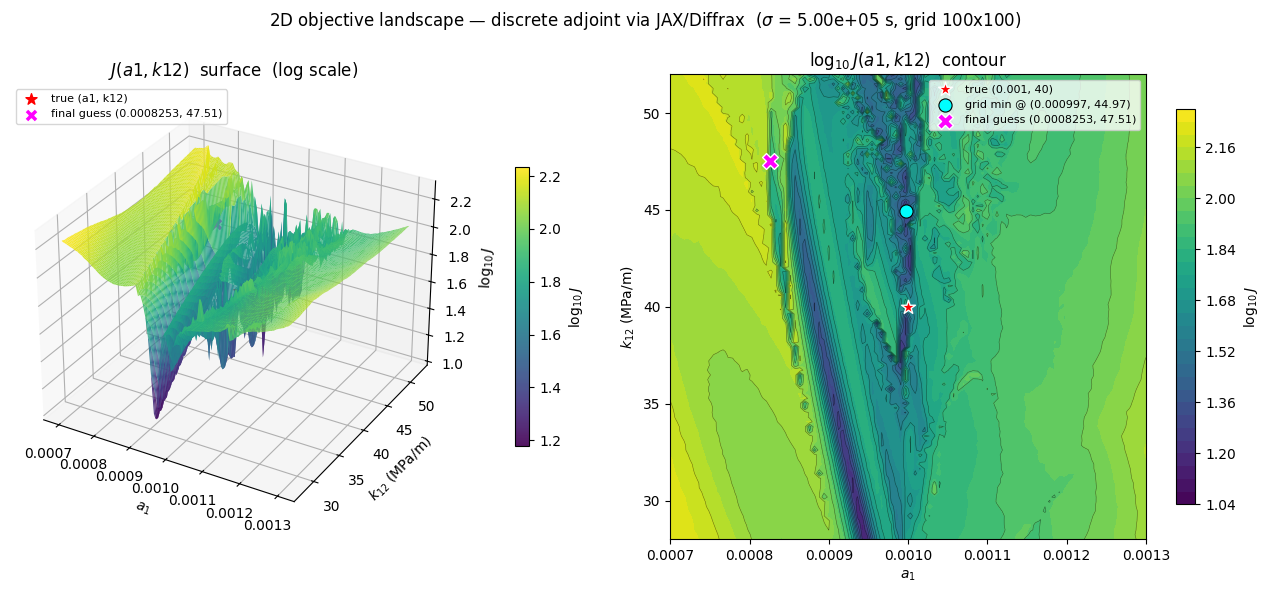


True location:  (a1=0.001, k12=40)
Grid minimum:   (a1=0.00099697, k12=44.97)
  J at true grid pt = 5.216e+01
  J at grid min     = 1.139e+01
Final guess:    (a1=0.00082532, k12=47.509)
  J at final-guess grid pt = 7.015e+01


In [35]:
from adjoint_tests import run_J_landscape_2d_jax

# Build {param_name: final_value} from the inversion result so the landscape
# plot can mark where scipy.optimize landed. Keys present in `params=` below
# are the only ones read; others are ignored.
_p_final_2d = {name: float(x_final[i]) for i, name in enumerate(INVERT_PARAMS)}

landscape_2d_results = run_J_landscape_2d_jax(
    M=M,
    T=T,
    forward_solve_jax=forward_solve_jax,
    u1_obs=np.asarray(u1_obs),
    u2_obs=np.asarray(u2_obs),
    t_ref=np.asarray(t_ref),
    params=('a1', 'k12'),
    n1=100,
    n2=100,
    sigma=0.01*T,
    chunk_size=32,
    p_final=_p_final_2d,
)
